In [29]:
                                        #----Probabilistic Equity Valuation using Monte Carlo Simulation----#

import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from datetime import timedelta
from scipy.stats import norm
from scipy.stats import skew

In [30]:
Tickers=["AAPL", "MSFT", "GOOGL" ,"ADBE",  "V" , "MA" , "NVDA" , "CAT", "AIR.PA", "SIE.DE"]
NomsEntreprises=["Apple" ,"Microsoft", "Google" , "Adobe" , "VISA" , "Mastercard" ,"Nvidia", "Caterpillar", "Airbus", "Siemens"]

#Dictionnaire de états financiers pour sécuriser l'import de données
Labels = {
    "revenue": ["Total Revenue"],
    "ebitda": ["EBITDA"],
    "capex": ["Capital Expenditure"],
    "depreciation": [
        "Depreciation And Amortization",
        "Depreciation",
        "Depreciation Amortization Depletion"
    ],
    "receivables": ["Accounts Receivable", "Receivables"],
    "payables": ["Accounts Payable", "Payables"],
    "inventory": ["Inventory"],
    "interest_expense": ["Interest Expense", "Interest And Debt Expense"],
    "total_debt": ["Total Debt", "Short Long Term Debt Total"],
    "tax_provision": ["Tax Provision"],
    "pre_tax_income": ["Pretax Income", "Pre Tax Income"],
    "end_cash_postion": ["End Cash Position"]
}

def getLine(df,keys):
    for key in keys:
        if key in df.index:
            return df.loc[key]
    else:
        #Retourne une ligne de zéros avec le bon index temporel si la valeur n'est pas trouvée
        return pd.Series(0, index=df.columns)

In [31]:
def ChoixEntreprise():
    #Affichage de la liste des entreprises
    print(f"Entreprises Disponibles : ", flush=True)
    print(f" | ".join(f"{i+1} - {Nom}" for i, Nom in enumerate(NomsEntreprises)), flush=True)
    NomsEntreprisesLower=[Nom.lower() for Nom in NomsEntreprises]
    #Choix utilisateur de l'entreprise
    while True:
        choix=str(input("Saisissez le nom d'une entreprise de la liste : ")).lower()
        if choix in NomsEntreprisesLower:
            break
        print("Entreprise Inconnue.")
    #Récupération du Ticker par indéxation
    indice=NomsEntreprisesLower.index(choix)
    Ticker=Tickers[indice]
    return Ticker

Ticker = ChoixEntreprise()

Entreprises Disponibles : 
1 - Apple | 2 - Microsoft | 3 - Google | 4 - Adobe | 5 - VISA | 6 - Mastercard | 7 - Nvidia | 8 - Caterpillar | 9 - Airbus | 10 - Siemens


In [32]:
def TéléchargementDonnées(Ticker):
    Entreprise=yf.Ticker(Ticker)  #Accès aux données de l'entreprise choisie
    Revenus=Entreprise.income_stmt  #Revenu
    CashFlow=Entreprise.cash_flow  #Trésorerie 
    Balance=Entreprise.balance_sheet  #Bilan

    CA=getLine(Revenus, Labels["revenue"])  #Accès via la fonction getLine au CA en parcourant les valeurs de la clé "revenue" du dictionnaire Labels
    EBITDA=getLine(Revenus, Labels["ebitda"])  #Accès via la fonction getLine à l'EBITDA en parcourant les valeurs de la clé "EBITDA" du dictionnaire Labels
    Capex = getLine(CashFlow, Labels["capex"])  #Accès via la fonction getLine au Capital Expenditure en parcourant les valeurs de la clé "capex" du dictionnaire Labels
    Depreciation = getLine(CashFlow, Labels["depreciation"])  #Accès via la fonction getLine aux amortissements en parcourant les valeurs de la clé "depreciation" du dictionnaire Labels 

    Receivables = getLine(Balance, Labels["receivables"])  #Dettes Clients
    Payables = getLine(Balance, Labels["payables"])  #Dettes Fournisseurs
    Inventory = getLine(Balance, Labels["inventory"])  #Inventaire

    #Concaténation des Series
    Revenus=pd.DataFrame([CA,EBITDA])  
    CashFlow=pd.DataFrame([Capex,Depreciation])
    Balance=pd.DataFrame([Receivables,Payables,Inventory])
    
    return Revenus, CashFlow, Balance

Revenus , CashFlow , Balance = TéléchargementDonnées(Ticker)

In [33]:
def CalculKPI(Revenus, CashFlow , Balance):

    #On créé des indices pour accéder aux lignes des DataFrame
    revenue_key = Revenus.index[0]
    ebitda_key = Revenus.index[1]

    capex_key = CashFlow.index[0]
    dep_key = CashFlow.index[1]

    receivables_key = Balance.index[0]
    payables_key = Balance.index[1]
    inventory_key = Balance.index[2] if len(Balance.index) > 2 else None  #Pour éviter les inventaires inexistants

    #Alignement des années pour éviter les NaN
    common_cols = Revenus.columns.intersection(CashFlow.columns).intersection(Balance.columns)
    Revenus = Revenus[common_cols]
    CashFlow = CashFlow[common_cols]
    Balance = Balance[common_cols]

    #Revenu de départ pour les simulations de Monte Carlo
    Revenu_Initial=Revenus.loc[revenue_key].iloc[0]
    #Calcul de la croissance moyenne du chiffres d'affaires
    Growth_Revenue=Revenus.loc[revenue_key][::-1].pct_change().dropna()
    Growth_Revenue_mean=Growth_Revenue.mean()
    #Calcul du Net Working Capital par année -> sortie = DataFrame
    NWC=Balance.loc[receivables_key]+Balance.loc[inventory_key]-Balance.loc[payables_key]
    #Marge d'EBITDA

    EBITDA_margin=(Revenus.loc[ebitda_key]/Revenus.loc[revenue_key]).mean()
    #Ratio de dépréciation
    Depreciation_ratio=(CashFlow.loc[dep_key]/Revenus.loc[revenue_key]).mean()
    #Ratio CAPEX (Capital Expenditure)
    CAPEX_ratio=(CashFlow.loc[capex_key]/Revenus.loc[revenue_key]).mean()
    #Ratio NWC
    NWC_ratio=(NWC/Revenus.loc[revenue_key]).dropna().mean()

    return Revenu_Initial, Growth_Revenue, Growth_Revenue_mean, EBITDA_margin, Depreciation_ratio, CAPEX_ratio, NWC_ratio

Revenu_Initial,Growth_Revenue, Growth_Revenue_mean, EBITDA_margin, Depreciation_ratio, CAPEX_ratio, NWC_ratio=CalculKPI(Revenus, CashFlow, Balance)
print(f"Revenu de {Ticker} en 2026 : {Revenu_Initial:.2f}$")
print(f"Croissance moyenne du CA de {Ticker} : {Growth_Revenue_mean*100:.4f}%")
print(f"Marge moyenne d'EBITDA de {Ticker} : {EBITDA_margin*100:.4f}%")
print(f"Dépréciation moyenne des actifs de {Ticker} : {Depreciation_ratio*100:.4f}%")
print(f"Dépense moyenne d'investissements de {Ticker} : {CAPEX_ratio*100:.4f}%")
print(f"Capital nécessaire au financement de l’activité courante de {Ticker} : {NWC_ratio*100:.4f}%")

Revenu de AIR.PA en 2026 : 73420000000.00$
Croissance moyenne du CA de AIR.PA : 7.7357%
Marge moyenne d'EBITDA de AIR.PA : 13.2623%
Dépréciation moyenne des actifs de AIR.PA : 4.1090%
Dépense moyenne d'investissements de AIR.PA : -4.8884%
Capital nécessaire au financement de l’activité courante de AIR.PA : 31.4228%


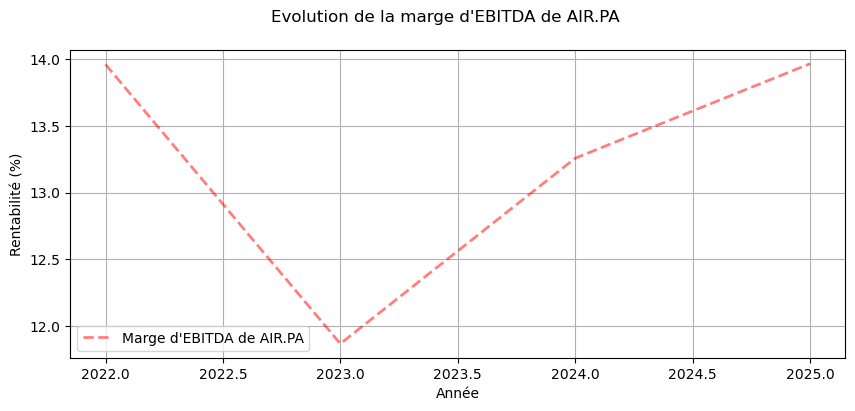

In [34]:
#Graphique de l'évolution du taux de la marge d'EBITDA
def Graphique():

    revenue_key = Revenus.index[0]
    ebitda_key = Revenus.index[1]

    Margins=Revenus.loc[ebitda_key]/Revenus.loc[revenue_key]*100
    FlippedMargins=Margins[::-1]
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(FlippedMargins.index.year, FlippedMargins, label=f"Marge d'EBITDA de {Ticker}" , linewidth=2 , linestyle="dashed" , color="red" , alpha=0.5) 
    ax.set_xlabel("Année")
    ax.set_ylabel("Rentabilité (%)")
    ax.grid(True)
    fig.suptitle(f"Evolution de la marge d'EBITDA de {Ticker}")
    plt.legend()
    plt.show()
    
Plot=Graphique()

In [35]:
#Récupération des écarts-types pour les simulations de Monte Carlo
def StdParam(Revenus , Balance):
    
    revenue_key = Revenus.index[0]
    ebitda_key = Revenus.index[1]

    capex_key = CashFlow.index[0]
    dep_key = CashFlow.index[1]

    receivables_key = Balance.index[0]
    payables_key = Balance.index[1]
    inventory_key = Balance.index[2]

    EBITDA_std=(Revenus.loc[ebitda_key]/Revenus.loc[revenue_key]).std()
    NWC_std=((Balance.loc[receivables_key]+Balance.loc[inventory_key]-Balance.loc[payables_key])/Revenus.loc[revenue_key]).std()
    Growth_Revenue_std=Growth_Revenue.std()
    return Growth_Revenue_std , EBITDA_std , NWC_std

Growth_Revenue_std, EBITDA_std , NWC_std = StdParam(Revenus, Balance)
print(f"Ecart type de la croissance de {Ticker} : {Growth_Revenue_std:.4f}")
print(f"Ecart type de l'EBITDA de {Ticker} : {EBITDA_std:.4f}")
print(f"Ecart type du NWC de {Ticker} : {NWC_std:.4f}")

Ecart type de la croissance de AIR.PA : 0.0315
Ecart type de l'EBITDA de AIR.PA : 0.0099
Ecart type du NWC de AIR.PA : 0.0252


In [36]:
#Calcul du Beta de l'action pour une estimation du coût des fonds propres
def Beta():
    #Choix de l'indice de référence
    Cours=[Ticker]
    Benchmark=["S&P 500", "STOXX 600"]
    Benchmark_Ticker=["^GSPC", "^STOXX"]
    print(" | ".join(f"{i+1} - {reference}" for i, reference in enumerate(Benchmark)), flush=True)
    while True:
        ref=int(input(print(f"Choisissez votre indice de référence (1/2):",flush=True)))
        if ref in [1,2]:
            indice=Benchmark_Ticker[ref-1]
            break
        else:
            print("Erreur de saisie")
    Cours.append(indice)
    Benchmark_ref=Benchmark[ref-1]
    
    #Téléchargement des cours du Benchmark
    years=15
    endDate=dt.datetime.now()
    startDate=endDate-dt.timedelta(years*365)
    Data=yf.download(Cours, start=startDate, end=endDate,auto_adjust=True,progress=False)["Close"]

    #Calcul des rendements discrets
    Returns=Data.pct_change(fill_method=None).dropna()
    Mean_Annual_Returns=Returns[indice].mean()*252
    print(f"Rendement moyen du marché : {Mean_Annual_Returns*100:.4f}%")

    #MCO sur les rendements pour estimer le Beta de l'actif
    beta , alpha=np.polyfit(Returns[indice], Returns[Ticker],1)
    return beta, alpha , Benchmark_ref , indice , Mean_Annual_Returns

beta, alpha, Benchmark_ref, indice, Mean_Annual_Returns=Beta()
print(f"Beta de l'action {Ticker} par rapport au {Benchmark_ref} ({indice}) : {beta:.4f}")
    

1 - S&P 500 | 2 - STOXX 600
Choisissez votre indice de référence (1/2):
Rendement moyen du marché : 6.7466%
Beta de l'action AIR.PA par rapport au STOXX 600 (^STOXX) : 1.3575


In [37]:
def computeWACC(Ticker):

    endDate=dt.datetime.now() 
    startDate=endDate-dt.timedelta(365)

    #Récupération du taux sans risque
    Rf=yf.download("^TNX", start=startDate, end=endDate, auto_adjust=True, progress=False)["Close"].iloc[-1].item()/100  #.iloc[-1] pour sélectionner la dernière valeur
    print(f"Taux à 10 ans des bons du trésor public Américain : {Rf*100:.4f}%")
    #Prime de risque de marché
    #---Market_Risk_Premium=Mean_Annual_Returns-Rf -> prime de marché trop élevé par les rendements historiques
    Market_Risk_Premium=0.055
    print(f"Prime de risque du marché : {Market_Risk_Premium*100:.4f}%")
    #Approximation du coût des fonds propres par le CAPM
    Cost_Of_Equity=Rf+beta*Market_Risk_Premium #Equivalent au rendement minimum attendu par les investisseurs

    #Calcul du coût de la dette
    Entreprise=yf.Ticker(Ticker)
    #Dépenses de remboursements d'intérêts
    InterestExpense=getLine(Entreprise.income_stmt,Labels["interest_expense"]).dropna().iloc[0]  #.iloc pour sélectionner la première ligne
    #Dette totale
    D=getLine(Entreprise.balance_sheet, Labels["total_debt"]).dropna().iloc[0]
    if pd.isna(InterestExpense) or D==0:
        Cost_Of_Debt=0
    else:
        Cost_Of_Debt=abs(InterestExpense)/D  #Equivalent au taux d'emprunt moyen de l'entreprise
    
    #Capitalisation de marché
    E=Entreprise.info["marketCap"]

    #Taux d'imposition
    Tax_Rate=getLine(Entreprise.income_stmt, Labels["tax_provision"]).dropna().iloc[0]/getLine(Entreprise.income_stmt, Labels["pre_tax_income"]).dropna().iloc[0]

    #WACC
    WACC=(E/(D+E))*Cost_Of_Equity+(D/(D+E))*Cost_Of_Debt*(1-Tax_Rate)
    #---WACC=0.0850
    return WACC , Cost_Of_Equity ,  Cost_Of_Debt , Tax_Rate , D

WACC, Cost_Of_Equity, Cost_Of_Debt ,Tax_Rate , Total_Debt =computeWACC(Ticker)
print(f"Cost of Equity : {Cost_Of_Equity*100:.4f}%")
print(f"Cost of Debt : {Cost_Of_Debt*100:.4f}%")
print(f"Weighted Average Cost of Capital de {Ticker} : {WACC*100:.4f}%")

Taux à 10 ans des bons du trésor public Américain : 4.2850%
Prime de risque du marché : 5.5000%
Cost of Equity : 11.7512%
Cost of Debt : 6.9854%
Weighted Average Cost of Capital de AIR.PA : 11.2685%


In [38]:
                                                        #---Simulations---#

def simsMonteCarlo(years,iterations):
    #Simulations du taux de croissance du Chiffres d'Affaires
    revenue_growth_dist=np.random.normal(loc=Growth_Revenue_mean, scale=Growth_Revenue_std, size=(years,iterations))+1
    #Calcul du taux de croissance cumulé du Chiffres d'Affaires
    #Axis=0 -> produits cumulés verticaux
    revenue_growth_dist=np.cumprod(revenue_growth_dist, axis=0)
    #Chiffre d'Affaires simulé
    Revenu_MC=Revenu_Initial*revenue_growth_dist  #Matrice de taille (years,iterations)

    #Marges d'EBITDA simulées
    ebitda_margin_dist=np.random.normal(loc=EBITDA_margin, scale=EBITDA_std, size=(years,iterations))
    #EBITDA simulés
    EBITDA=Revenu_MC*ebitda_margin_dist  #Matrice de taille (years,iterations)

    #Calcul de l'EBIT
    Depreciation=Revenu_MC*Depreciation_ratio  #Matrice de taille (years,iterations)
    EBIT=EBITDA - Depreciation

    #Impôts
    Tax=-EBIT*Tax_Rate

    #Simulations du besoin en fonds de roulement
    nwc_ratio_dist=np.random.normal(loc=NWC_ratio, scale=NWC_std, size=(years,iterations))
    NWC=Revenu_MC*nwc_ratio_dist  #Matrice de taille (years,iterations)
    
    #Calcul des ΔNWC
    #Création d'une ligne NWC0 avec le NWC à l'instant t pour calculer les variations sur 5 années (perte d'une année sinon -> début des projections en t+2)
    NWC0_row=np.full((1,iterations),Revenu_Initial*NWC_ratio)
    #On ajoute la ligne verticalement à la matrice des NWC simulés
    NWC=np.vstack((NWC0_row,NWC))
    Lignes,Colonnes=NWC.shape
    #Création d'une matrice vide que l'on remplit des variations des BFR (NWCt-1-NWCt) 
    #Longueur : 5 lignes ->Variations sur 5 années grace à la ligne NWC0 ajoutée
    #Largeur : 10,000 colonnes ->Nombre d'itérations
    deltaNWC=np.zeros((Lignes-1,Colonnes))
    for i in range(1,Lignes):
        for j in range(0,Colonnes):
            varNWC=NWC[i-1,j]-NWC[i,j]
            deltaNWC[i-1,j]=varNWC
        
    #Calcul du Capex
    Capex=-Revenu_MC*CAPEX_ratio

    #Free Cash Flow sur données simulées
    FCF = EBITDA + Tax + deltaNWC + Capex

    #Calcul de la Terminal Value 
    # ->TV=(FCFt+1)/(WACC-g) avec g le taux de de croissance de la firme
    # FCFt+1 = FCFt(1+g)
    g_dist=np.random.lognormal(mean=np.log(0.025), sigma=0.10, size=iterations)
    #On borne la valeur du taux de croissance pour sécuriser le calcul de la TV
    g_dist=np.clip(g_dist, 0.015 , WACC-0.005)
    TV=FCF[-1]*(1+g_dist)/(WACC-g_dist)
    #On actualise la TV à la dernière année des simulations
    updated_TV=TV/(1+WACC)**years

    #Création des facteurs d'actualisation
    t=np.arange(1,years+1)  #Vecteur des horizons
    discount_rates=1/(1+WACC)**t  #Vecteur des facteurs d'actualisation

    #Calcul de la somme des FCF actualisés -> .reshape pour transformer le vecteur de dimension (x,) en une matrice (x,1) pour le calcul matriciel
    DCF_value=np.sum(FCF*discount_rates.reshape(len(discount_rates),1), axis=0)+updated_TV

    return DCF_value

DCF_value=simsMonteCarlo(5,10000)

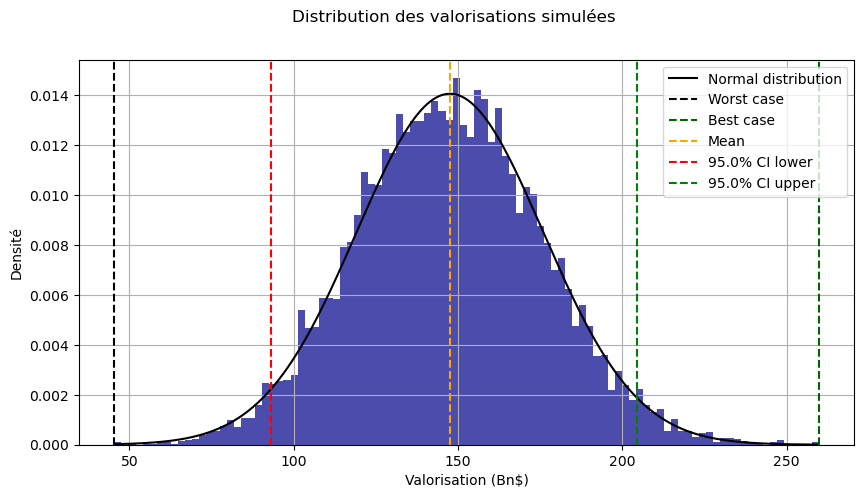

--- Résultats de la simulation Monte Carlo ---
Valorisation estimée : 147.52 Bn$
Intervalle de confiance à 95% : 93.23 Bn$ ; 204.44 Bn$
Skewness de la distribution : 0.094
Scénario le plus pessimiste : 45.43 Bn$
Scénario le plus optimiste  : 259.78 Bn$


In [39]:
                                    #---Statistiques de la distribution & Graphiques---#

def plotDistrib(DCF_value):
    #Statistiques descriptives et percentiles
    #Division par 1e9 pour échelonner en milliard la valorisation 
    minimum=(DCF_value/1e9).min()
    maximum=(DCF_value/1e9).max()
    moyenne=(DCF_value/1e9).mean()
    std_DCF=(DCF_value/1e9).std()
    quantile_inf5=np.percentile(DCF_value/1e9,2.5)
    quantile_sup5=np.percentile(DCF_value/1e9,97.5)
    skewness=skew(DCF_value/1e9)
    confidence_level=0.95

    #Ajout d'une distribution normale
    x = np.linspace(minimum, maximum, 10000)
    y = norm.pdf(x, moyenne, std_DCF)

    fig , ax=plt.subplots(figsize=(10,5))
    #Histogramme de la valorisation
    ax.hist(DCF_value/1e9, bins=100, density=True, histtype="bar" , alpha=0.7 , color="darkblue")
    #Plot de la distribution normale
    ax.plot(x,y , label="Normal distribution" , color="black")

    #Ajout des Statistiques descriptives et percentiles à l'histogramme
    ax.axvline(minimum, label="Worst case" , color="black" , linestyle="--")
    ax.axvline(maximum, label="Best case", color="darkgreen" , linestyle="--")
    ax.axvline(moyenne, label="Mean" , color="orange" , linestyle="--")
    ax.axvline(quantile_inf5, label=f"{confidence_level*100}% CI lower", color="red" , linestyle="--")
    ax.axvline(quantile_sup5, label=f"{confidence_level*100}% CI upper", color="green" , linestyle="--")
    #Labels des axes et titre du graphique
    ax.set_xlabel("Valorisation (Bn$)")
    ax.set_ylabel("Densité")
    fig.suptitle("Distribution des valorisations simulées")

    ax.grid(True)
    plt.legend()
    plt.show()

    #Affichage des résultats
    print("--- Résultats de la simulation Monte Carlo ---")
    print(f"Valorisation estimée : {moyenne:,.2f} Bn$")
    print(f"Intervalle de confiance à {confidence_level*100:.0f}% : {quantile_inf5:,.2f} Bn$ ; {quantile_sup5:,.2f} Bn$")
    print(f"Skewness de la distribution : {skewness:.3f}")
    print(f"Scénario le plus pessimiste : {minimum if minimum>0 else 0:,.2f} Bn$")
    print(f"Scénario le plus optimiste  : {maximum:,.2f} Bn$")

plotDistrib(DCF_value)


--- Equity Value per share ---
Cours actuel : 168.14$
Average Fair Value : $ 190.85 - Standard deviation: $ 35.93
Interprétation : l'action semble sous-évaluée par le marché 
Upside potentiel : 13.50%  - Probabilité : >73%
Worst case: $ 61.51 - Best case: $ 333.08
Intervalle de confiance à 95% : 122.07$ ; 262.97$


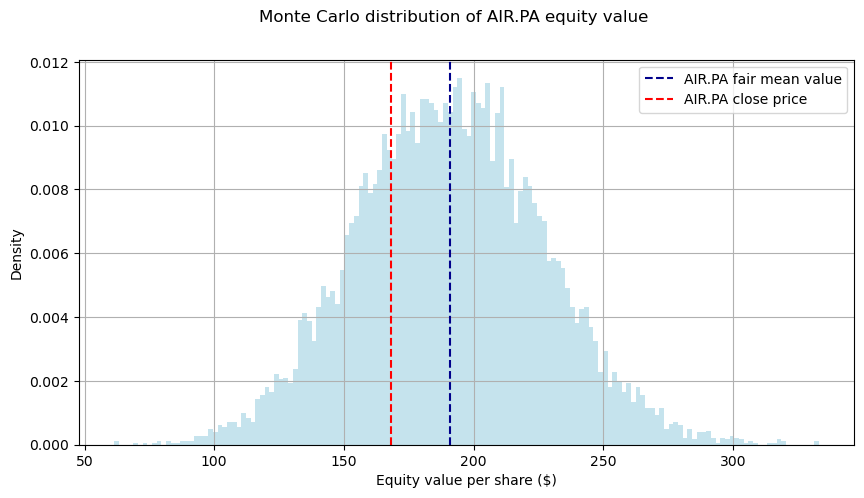

In [40]:
                                                #---Projection de la valeur de l'Equity---#
def equityValue(DCF_value, Ticker):
    Entreprise=yf.Ticker(Ticker)
    Cash=getLine(Entreprise.cash_flow,Labels["end_cash_postion"]).dropna().iloc[0]
    Equity_Value=DCF_value+Cash-Total_Debt
    #Nombre d'actions
    nShares=Entreprise.get_shares_full().iloc[-1]
    #Prix par action simulé
    price_per_share=Equity_Value/nShares

    
    #Prix Actuel
    endDate=dt.datetime.now()
    startDate=endDate-dt.timedelta(365)
    cours_ticker=yf.download(Ticker, start=startDate, end=endDate, auto_adjust=True, progress=False)["Close"].iloc[-1].item()
    #Statistiques
    moyenne=np.mean(price_per_share)
    minimum=np.min(price_per_share)
    maximum=np.max(price_per_share)
    std=np.std(price_per_share)
    quantile_inf5=np.percentile(price_per_share,2.5)
    quantile_sup5=np.percentile(price_per_share,97.5)
    confidence_level=0.95

    p_overvalued=np.mean(price_per_share<cours_ticker)
    p_undervalued=np.mean(price_per_share>cours_ticker)

    #Calcul de l'Upside
    Upside=moyenne/cours_ticker-1
    if Upside > 0.10:
        interpretation = f"l'action semble sous-évaluée par le marché \nUpside potentiel : {Upside*100:.2f}%  - Probabilité : >{min(p_undervalued*100,99):.0f}%"
    elif Upside < -0.10:
        interpretation = f"l'action semble sur-évaluée par le marché \nDownside potentiel : {abs(Upside)*100:.2f}% - Probabilité : >{min(p_overvalued*100,99):.0f}%"
    else:
        interpretation = f"l'action semble proche de sa valeur fondamentale \nProbabilité que l'action soit sur-évaluée : {p_overvalued*100:.2f}% \nProbabilité que l'action soit sous-évaluée : {p_undervalued*100:.2f}"
    
    #Affichage des résultats
    print("--- Equity Value per share ---")
    print(f"Cours actuel : {cours_ticker:.2f}$")
    print(f"Average Fair Value : $ {moyenne:.2f} - Standard deviation: $ {std:.2f}")
    print(f"Interprétation : {interpretation}")
    print(f"Worst case: $ {minimum if minimum>0 else 0:.2f} - Best case: $ {maximum:.2f}")
    print(f"Intervalle de confiance à {confidence_level*100:.0f}% : {quantile_inf5:.2f}$ ; {quantile_sup5:.2f}$")

    fig, ax=plt.subplots(figsize=(10,5))
    ax.hist(price_per_share, bins=150,density=True, histtype="bar", color="lightblue", alpha=0.7)
    ax.axvline(moyenne, label=f"{Ticker} fair mean value" , color="darkblue" , linestyle="--")
    ax.axvline(cours_ticker, label=f"{Ticker} close price", color="red", linestyle="--")
    ax.grid(True)
    ax.set_xlabel("Equity value per share ($)")
    ax.set_ylabel("Density")
    fig.suptitle(f"Monte Carlo distribution of {Ticker} equity value")
    plt.legend()
    plt.savefig("equity_distribution.png", dpi=300)
    plt.show()

equityValue(DCF_value, Ticker)